In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
!wget https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip -O dataset-resized.zip

!unzip -q dataset-resized.zip -d dataset

print("Dataset downloaded successfully!")

--2026-06-29 08:30:23--  https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip [following]
--2026-06-29 08:30:23--  https://raw.githubusercontent.com/garythung/trashnet/master/data/dataset-resized.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42834870 (41M) [application/zip]
Saving to: ‘dataset-resized.zip’

dataset-resized.zip 100%[===================>]  40.85M  --.-KB/s    in 0.1s    

2026-06-29 08:30:25 (312 MB/s) - ‘dataset-resized.zip’ saved [42834870/42834870]

Data

In [ ]:
!rm -rf dataset/__MACOSX
!find dataset -name ".DS_Store" -delete

In [ ]:
DATASET_DIR = "dataset/dataset-resized"

classes = sorted(os.listdir(DATASET_DIR))

print("Classes Found:")
print(classes)

print(f"\nTotal Classes: {len(classes)}")

Classes Found:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Total Classes: 6


In [ ]:
DATASET_DIR = "dataset/dataset-resized"

classes = sorted(os.listdir(DATASET_DIR))

print("Classes Found:")
print(classes)

print(f"\nTotal Classes: {len(classes)}")

Classes Found:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Total Classes: 6


In [ ]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)
    image_count = len(os.listdir(class_path))
    class_counts[class_name] = image_count

print("Number of Images in Each Class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print(f"\nTotal Images: {sum(class_counts.values())}")

Number of Images in Each Class:

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137

Total Images: 2527


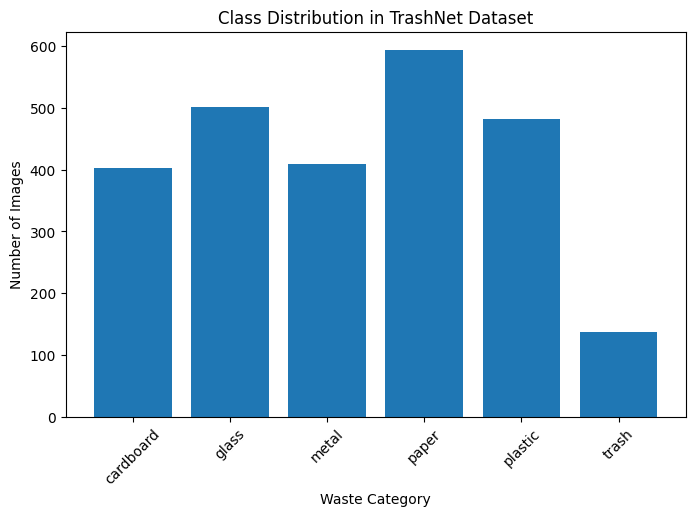

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution in TrashNet Dataset")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

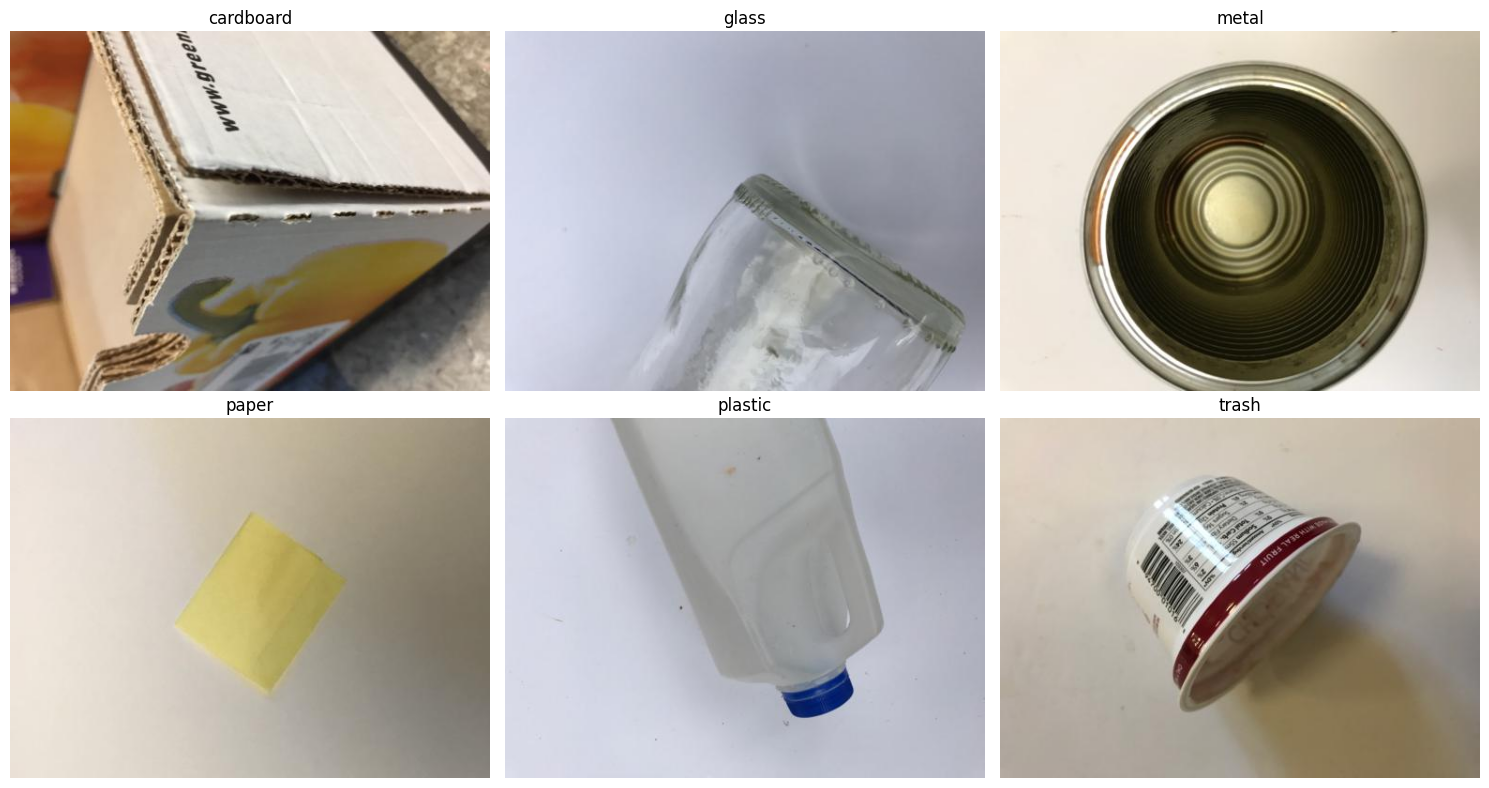

In [ ]:
plt.figure(figsize=(15, 8))

for index, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_DIR, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    image = plt.imread(image_path)
    plt.subplot(2, 3, index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
image_paths = []
labels = []

for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image_paths.append(image_path)
        labels.append(class_name)

print(f"Total Images : {len(image_paths)}")
print(f"Total Labels : {len(labels)}")

Total Images : 2527
Total Labels : 2527


In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=SEED
)

print(f"Training + Validation Images : {len(X_train_val)}")
print(f"Testing Images               : {len(X_test)}")

Training + Validation Images : 2147
Testing Images               : 380


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    stratify=y_train_val,
    random_state=SEED
)

print(f"Training Images   : {len(X_train)}")
print(f"Validation Images : {len(X_val)}")
print(f"Testing Images    : {len(X_test)}")

Training Images   : 1768
Validation Images : 379
Testing Images    : 380


In [ ]:
import pandas as pd

train_df = pd.DataFrame({
    "filename": X_train,
    "class": y_train
})

val_df = pd.DataFrame({
    "filename": X_val,
    "class": y_val
})

test_df = pd.DataFrame({
    "filename": X_test,
    "class": y_test
})

print("Training DataFrame Shape :", train_df.shape)
print("Validation DataFrame Shape:", val_df.shape)
print("Testing DataFrame Shape :", test_df.shape)

train_df.head()

Training DataFrame Shape : (1768, 2)
Validation DataFrame Shape: (379, 2)
Testing DataFrame Shape : (380, 2)


,filename,class
0,dataset/dataset-resized/paper/paper542.jpg,paper
1,dataset/dataset-resized/metal/metal52.jpg,metal
2,dataset/dataset-resized/plastic/plastic205.jpg,plastic
3,dataset/dataset-resized/paper/paper287.jpg,paper
4,dataset/dataset-resized/paper/paper302.jpg,paper


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1768 validated image filenames belonging to 6 classes.
Found 379 validated image filenames belonging to 6 classes.
Found 380 validated image filenames belonging to 6 classes.


In [ ]:
# base_model = VGG16(
#     weights="imagenet",
#     include_top=False,
#     input_shape=(224, 224, 3)
# )

# base_model.trainable = False

# print("Trainable Layers:", len(base_model.trainable_weights))
# print("Non-Trainable Layers:", len(base_model.non_trainable_weights))

In [ ]:
# x = base_model.output

# x = GlobalAveragePooling2D()(x)

# x = Dense(
#     256,
#     activation="relu")(x)

# x = Dropout(0.5)(x)

# predictions = Dense(
#     len(classes),
#     activation="softmax")(x)

# model = Model(
#     inputs=base_model.input,
#     outputs=predictions
# )

# model.summary()

In [ ]:
# optimizer = tf.keras.optimizers.Adam(
#     learning_rate=1e-3
# )

# model.compile(
#     optimizer=optimizer,
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# print("Model compiled successfully!")

In [ ]:
# early_stopping = EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )

# model_checkpoint = ModelCheckpoint(
#     "vgg16_transfer_learning.keras",
#     monitor="val_accuracy",
#     save_best_only=True,
#     mode="max",
#     verbose=1
# )

# callbacks = [
#     early_stopping,
#     model_checkpoint
# ]

In [ ]:
# history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=30,
#     callbacks=callbacks,
#     verbose=1
# )

In [ ]:
# base_model.trainable = True

# for layer in base_model.layers:
#     layer.trainable = False

# unfreeze = False

# for layer in base_model.layers:
#     if layer.name == "block5_conv1":
#         unfreeze = True

#     if unfreeze:
#         layer.trainable = True

In [ ]:
# fine_tune_optimizer = tf.keras.optimizers.Adam(
#     learning_rate=1e-5
# )

# model.compile(
#     optimizer=fine_tune_optimizer,
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [ ]:
# fine_tune_history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=15,
#     callbacks=callbacks,
#     verbose=1
# )

In [ ]:
# test_loss, test_accuracy = model.evaluate(
#     test_generator,
#     verbose=1
# )

# print(f"\nTest Loss     : {test_loss:.4f}")
# print(f"Test Accuracy : {test_accuracy:.4f}")

In [ ]:
# predictions = model.predict(
#     test_generator,
#     verbose=1
# )

# y_pred = np.argmax(
#     predictions,
#     axis=1
# )

# y_true = test_generator.classes

# print("Number of Test Images :", len(y_true))
# print("Number of Predictions :", len(y_pred))

In [ ]:
# from sklearn.metrics import classification_report

# print(
#     classification_report(
#         y_true,
#         y_pred,
#         target_names=classes
#     )
# )

In [ ]:
# from sklearn.metrics import confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# cm = confusion_matrix(
#     y_true,
#     y_pred
# )

# plt.figure(figsize=(8, 6))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=classes,
#     yticklabels=classes
# )

# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()

In [ ]:
# model.save("vgg16_finetuned_trashnet.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("vgg16_finetuned_trashnet.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=5e-5
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled successfully.")

Model recompiled successfully.


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "vgg16_finetuned_v2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

In [ ]:
history_v2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.8901 - loss: 0.3089
Epoch 1: val_accuracy improved from None to 0.88390, saving model to vgg16_finetuned_v2.keras

Epoch 1: finished saving model to vgg16_finetuned_v2.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 67s 848ms/step - accuracy: 0.8778 - loss: 0.3362 - val_accuracy: 0.8839 - val_loss: 0.4601 - learning_rate: 5.0000e-05
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9115 - loss: 0.2634
Epoch 2: val_accuracy did not improve from 0.88390
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 514ms/step - accuracy: 0.9112 - loss: 0.2539 - val_accuracy: 0.8628 - val_loss: 0.5656 - learning_rate: 5.0000e-05
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9314 - loss: 0.1960
Epoch 3: val_accuracy did not improve from 0.88390

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 486ms/step - accuracy: 0.9299 - loss: 0.2041 - val_accuracy: 0.8285 - val_loss: 0.6902 - 

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("vgg16_finetuned_v2.keras")
print("Best model loaded successfully.")

Best model loaded successfully.


In [ ]:
test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8711 - loss: 0.4576

Test Loss     : 0.4576
Test Accuracy : 0.8711


In [ ]:
import numpy as np

test_generator.reset()

y_pred_prob = best_model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = test_generator.classes

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

   cardboard       0.98      0.92      0.95        61
       glass       0.85      0.88      0.86        75
       metal       0.83      0.89      0.86        62
       paper       0.87      0.92      0.90        89
     plastic       0.92      0.79      0.85        72
       trash       0.65      0.71      0.68        21

    accuracy                           0.87       380
   macro avg       0.85      0.85      0.85       380
weighted avg       0.88      0.87      0.87       380



In [ ]:
print(train_df.columns)

Index(['filename', 'class'], dtype='object')


In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# train_labels = train_generator.classes

# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.unique(train_labels),
#     y=train_labels
# )

# class_weights = dict(enumerate(weights))

# print("Class Weights:\n")
# for class_name, class_index in train_generator.class_indices.items():
#     print(
#         f"{class_name:10s} : {class_weights[class_index]:.3f}"
#     )

Class Weights:

cardboard  : 1.045
glass      : 0.840
metal      : 1.030
paper      : 0.708
plastic    : 0.872
trash      : 3.102


In [ ]:
# history_class_weights = best_model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=6,
#     callbacks=callbacks,
#     class_weight=class_weights,
#     verbose=1
# )

Epoch 1/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9517 - loss: 0.1348
Epoch 1: val_accuracy did not improve from 0.91821
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 520ms/step - accuracy: 0.9502 - loss: 0.1522 - val_accuracy: 0.8945 - val_loss: 0.4683 - learning_rate: 2.5000e-05
Epoch 2/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9528 - loss: 0.1428
Epoch 2: val_accuracy did not improve from 0.91821
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 488ms/step - accuracy: 0.9502 - loss: 0.1437 - val_accuracy: 0.9103 - val_loss: 0.4155 - learning_rate: 2.5000e-05
Epoch 3/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9564 - loss: 0.1102
Epoch 3: val_accuracy did not improve from 0.91821
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 500ms/step - accuracy: 0.9615 - loss: 0.1163 - val_accuracy: 0.9077 - val_loss: 0.4338 - learning_rate: 2.5000e-05
Epoch 4/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9604 - loss: 0.1075
Epoch 4: val_accuracy did not improve from 0.91821

Epoch 4: ReduceLR

In [ ]:
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.losses import CategoricalCrossentropy

# loss_function = CategoricalCrossentropy(
#     label_smoothing=0.1
# )

# optimizer = Adam(
#     learning_rate=1e-5
# )

# best_model.compile(
#     optimizer=optimizer,
#     loss=loss_function,
#     metrics=["accuracy"]
# )

# print("Model compiled with Label Smoothing.")

Model compiled with Label Smoothing.


In [ ]:
# history_label_smoothing = best_model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=6,
#     callbacks=callbacks,
#     verbose=1
# )

Epoch 1/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9374 - loss: 0.8872
Epoch 1: val_accuracy did not improve from 0.91821
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 558ms/step - accuracy: 0.9367 - loss: 0.7743 - val_accuracy: 0.9156 - val_loss: 0.8327 - learning_rate: 1.0000e-05
Epoch 2/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9528 - loss: 0.6763
Epoch 2: val_accuracy did not improve from 0.91821

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 508ms/step - accuracy: 0.9519 - loss: 0.6694 - val_accuracy: 0.8997 - val_loss: 0.8241 - learning_rate: 1.0000e-05
Epoch 3/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9502 - loss: 0.6639
Epoch 3: val_accuracy did not improve from 0.91821
56/56 ━━━━━━━━━━━━━━━━━━━━ 29s 511ms/step - accuracy: 0.9570 - loss: 0.6607 - val_accuracy: 0.8997 - val_loss: 0.8088 - learning_rate: 5.0000e-06
Epoch 4/6
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9638 - loss:

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving aastha_watch.jpeg to aastha_watch.jpeg


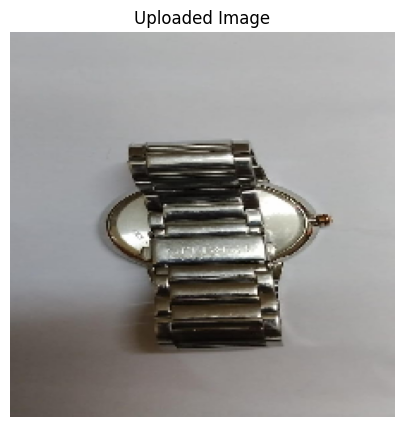

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

image_path = list(uploaded.keys())[0]

img = image.load_img(
    image_path,
    target_size=(224, 224)
)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# Convert PIL image to NumPy array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Apply VGG16 preprocessing
img_array = preprocess_input(img_array)

# Predict probabilities
predictions = best_model.predict(img_array)

# Get predicted class index
predicted_index = np.argmax(predictions)

# Get confidence
confidence = np.max(predictions)

# Convert index to class name
predicted_class = classes[predicted_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
# Convert prediction vector to 1D
predictions = predictions[0]

# Get indices of top 3 predictions
top3_indices = np.argsort(predictions)[::-1][:3]

print("=" * 40)
print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence * 100:.2f}%")
print("=" * 40)

print("\nTop 3 Predictions:\n")

for i, idx in enumerate(top3_indices, start=1):
    print(
        f"{i}. {classes[idx]:10s} : {predictions[idx] * 100:.2f}%"
    )

Predicted Class : metal
Confidence      : 96.98%

Top 3 Predictions:

1. metal      : 96.98%
2. trash      : 2.34%
3. glass      : 0.35%


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='captured_image.jpg', quality=0.9):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.body.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js(f'takePhoto({quality})')

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


image_path = take_photo()

print("Image saved as:", image_path)

<IPython.core.display.Javascript object>

Image saved as: captured_image.jpg


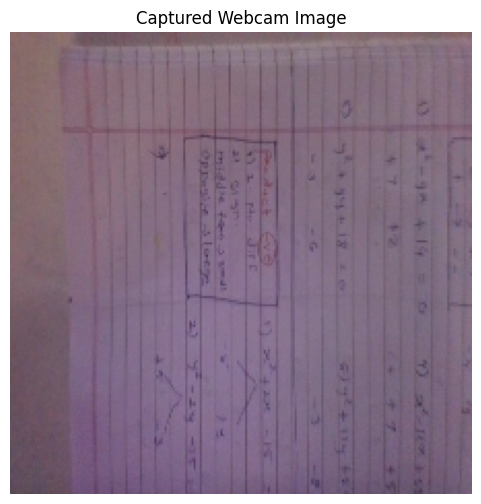

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

image_path = "captured_image.jpg"

img = image.load_img(
    image_path,
    target_size=(224, 224)
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Captured Webcam Image")
plt.show()

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)
predictions = best_model.predict(img_array)
predictions = predictions[0]
predicted_index = np.argmax(predictions)
predicted_class = classes[predicted_index]
confidence = predictions[predicted_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
top3 = np.argsort(predictions)[::-1][:3]

print("=" * 45)
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence * 100:.2f}%")
print("=" * 45)

print("\nTop 3 Predictions\n")

for rank, idx in enumerate(top3, start=1):
    print(
        f"{rank}. {classes[idx]:10s} : {predictions[idx] * 100:.2f}%"
    )